In [2]:
import pandas as pd
import numpy as np

dg1 = pd.read_csv("gaia_vs_synthpop_new_run.csv")
dg2 = pd.read_csv("l_gaia_vs_synthpop_stats_whole_grid.csv")

dg1["median_diff_l"] = dg1["gaia_l_median"] - dg1["synth_l_median"]
dg2["median_diff"]   = dg2["gaia_median"]   - dg2["synth_median"]

raw_vmin = np.nanmin([
    dg1["gaia_l_median"].min(), dg1["synth_l_median"].min(),
    dg2["gaia_median"].min(),   dg2["synth_median"].min()
])
raw_vmax = np.nanmax([
    dg1["gaia_l_median"].max(), dg1["synth_l_median"].max(),
    dg2["gaia_median"].max(),   dg2["synth_median"].max()
])

diff_max = np.nanmax([
    np.abs(dg1["median_diff_l"]).max(),
    np.abs(dg2["median_diff"]).max()
])
diff_vmin, diff_vmax = -diff_max, diff_max


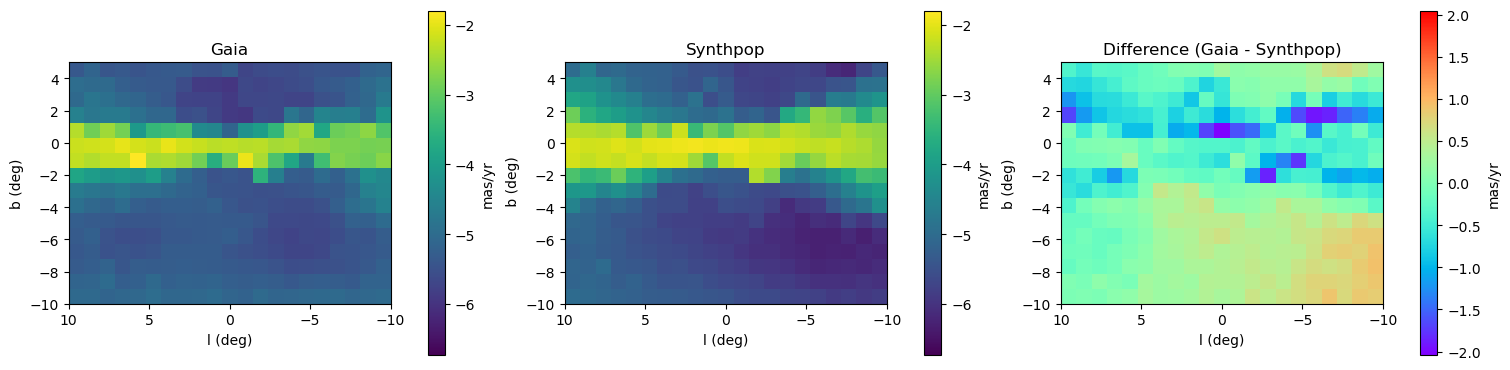

In [8]:
import synthpop 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

datagrid = pd.read_csv("gaia_vs_synthpop_new_run.csv")

datagrid["median_diff_l"] = datagrid["gaia_l_median"] - datagrid["synth_l_median"]

gaia_grid = datagrid.pivot(index="b", columns="l", values="gaia_l_median")
synth_grid = datagrid.pivot(index="b", columns="l", values="synth_l_median")
diff_grid = datagrid.pivot(index="b", columns="l", values="median_diff_l")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Gaia
gaia = axes[0].imshow(
    gaia_grid, origin="lower",
    extent=[gaia_grid.columns.min(), gaia_grid.columns.max(),
            gaia_grid.index.min(), gaia_grid.index.max()],
    aspect="equal", cmap="viridis", vmin=raw_vmin, vmax=raw_vmax
)
axes[0].set_title("Gaia")
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()


# Synthpop 
synthpop = axes[1].imshow(
    synth_grid, origin="lower",
    extent=[synth_grid.columns.min(), synth_grid.columns.max(),
            synth_grid.index.min(), synth_grid.index.max()],
    aspect="equal", cmap="viridis", vmin=raw_vmin, vmax=raw_vmax
)
axes[1].set_title("Synthpop")
axes[1].set_xlabel("l (deg)")
axes[1].set_ylabel(" b (deg)")
axes[1].invert_xaxis()


# Difference
gsdiff = axes[2].imshow(
    diff_grid, origin="lower",
    extent=[diff_grid.columns.min(), diff_grid.columns.max(),
            diff_grid.index.min(), diff_grid.index.max()],
    aspect="equal", cmap="rainbow", vmin=diff_vmin, vmax=diff_vmax
)
axes[2].set_title("Difference (Gaia - Synthpop)")
axes[2].set_xlabel("l (deg)")
axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()

# Add colorbars
fig.colorbar(gaia, ax=axes[0], orientation="vertical", label="mas/yr", shrink=0.7)
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label="mas/yr", shrink=0.7)
fig.colorbar(gsdiff, ax=axes[2], orientation="vertical", label="mas/yr", shrink=0.7)
plt.savefig("Synth-Gaia_new_run_heatmap_l.pdf")
plt.show()


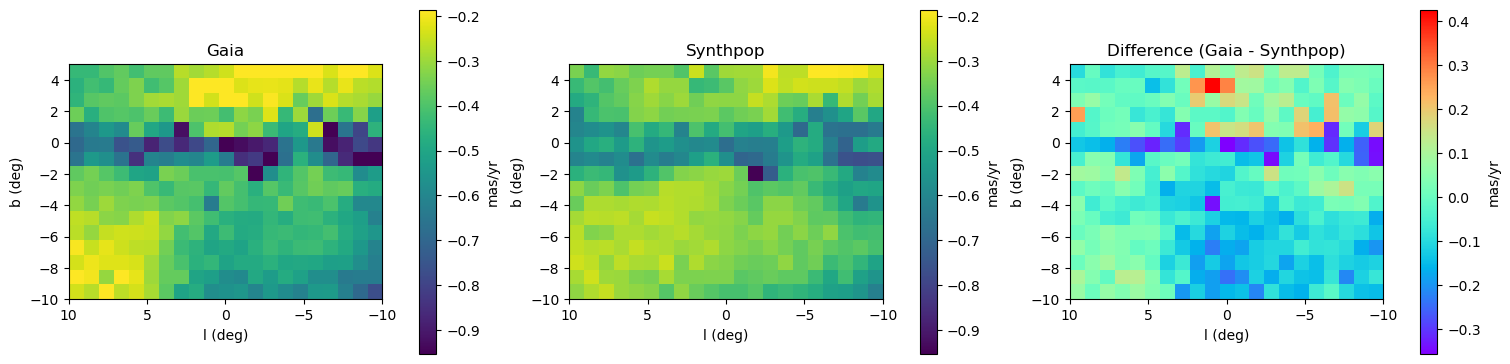

In [7]:
import synthpop 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

datagrid = pd.read_csv("gaia_vs_synthpop_new_run.csv")

datagrid["median_diff_b"] = datagrid["gaia_b_median"] - datagrid["synth_b_median"]

all_values = pd.concat([
    datagrid["gaia_b_median"],
    datagrid["synth_b_median"],
    datagrid["median_diff_b"]
])

vmin = np.min(datagrid["synth_b_median"])
vmax = np.max(datagrid["synth_b_median"])

gaia_grid = datagrid.pivot(index="b", columns="l", values="gaia_b_median")
synth_grid = datagrid.pivot(index="b", columns="l", values="synth_b_median")
diff_grid = datagrid.pivot(index="b", columns="l", values="median_diff_b")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Gaia
gaia = axes[0].imshow(gaia_grid, origin="lower",
                     extent=[gaia_grid.columns.min(), gaia_grid.columns.max(),
                             gaia_grid.index.min(), gaia_grid.index.max()],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Gaia")
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()


# Synthpop 
synthpop = axes[1].imshow(synth_grid, origin="lower",
                     extent=[synth_grid.columns.min(), synth_grid.columns.max(),
                             synth_grid.index.min(), synth_grid.index.max()],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Synthpop")
axes[1].set_xlabel("l (deg)")
axes[1].set_ylabel("b (deg)")
axes[1].invert_xaxis()


# Difference
gsdiff = axes[2].imshow(diff_grid, origin="lower",
                     extent=[diff_grid.columns.min(), diff_grid.columns.max(),
                             diff_grid.index.min(), diff_grid.index.max()],
                     aspect="equal", cmap="rainbow")
axes[2].set_title("Difference (Gaia - Synthpop)")
axes[2].set_xlabel("l (deg)")
axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()


# Add colorbars
fig.colorbar(gaia, ax=axes[0], orientation="vertical", label="mas/yr", shrink=0.7)
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label="mas/yr", shrink=0.7)
fig.colorbar(gsdiff, ax=axes[2], orientation="vertical", label="mas/yr", shrink=0.7)
plt.savefig("Synth-Gaia_new_run_heatmap_b.pdf")

plt.show()


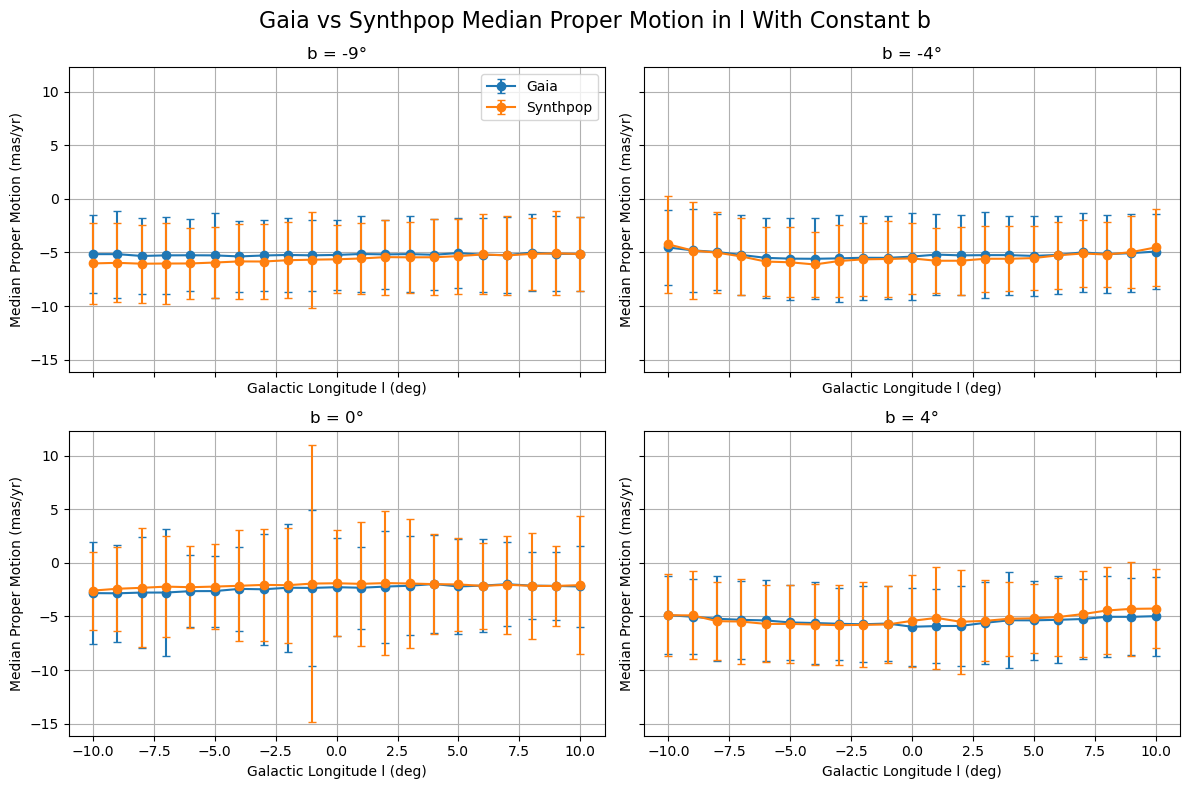

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gaia_vs_synthpop_new_run.csv")

b_values_to_plot = [-9, -4, 0, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, b_val in enumerate(b_values_to_plot):
    ax = axes[idx]
    
    df_b = df[df['b'] == b_val].sort_values(by='l')
    
    ax.errorbar(df_b['l'], df_b['gaia_l_median'], 
                yerr=df_b['gaia_l_std'], fmt='-o', label='Gaia',
                capsize=3, color='tab:blue')
    
    ax.errorbar(df_b['l'], df_b['synth_l_median'], 
                yerr=df_b['synth_l_std'], fmt='-o', label='Synthpop',
                capsize=3, color='tab:orange')
    
    ax.set_title(f"b = {b_val}°")
    ax.set_xlabel("Galactic Longitude l (deg)")
    ax.set_ylabel("Median Proper Motion (mas/yr)")
    ax.grid(True)
    if idx == 0:
        ax.legend()

fig.suptitle("Gaia vs Synthpop Median Proper Motion in l With Constant b", fontsize=16)
plt.tight_layout()
plt.show()


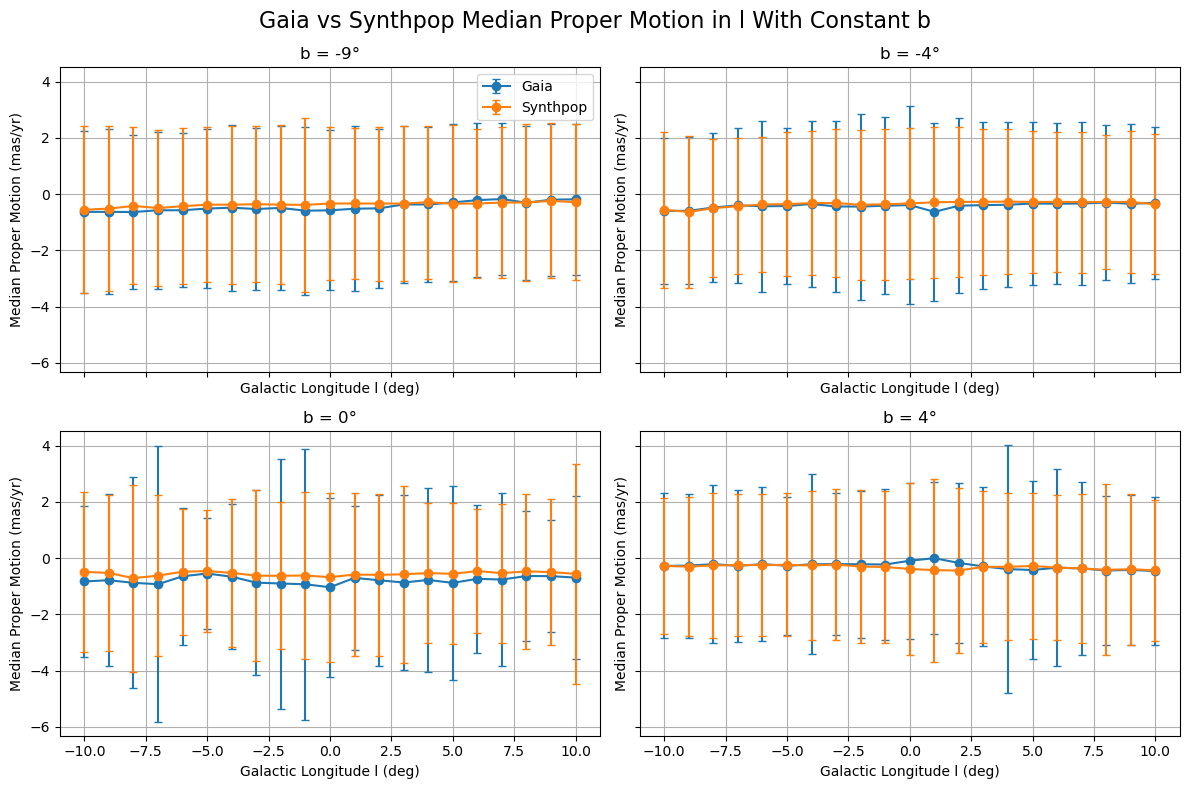

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gaia_vs_synthpop_new_run.csv")

b_values_to_plot = [-9, -4, 0, 4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, b_val in enumerate(b_values_to_plot):
    ax = axes[idx]
    
    df_b = df[df['b'] == b_val].sort_values(by='l')
    
    ax.errorbar(df_b['l'], df_b['gaia_b_median'], 
                yerr=df_b['gaia_b_std'], fmt='-o', label='Gaia',
                capsize=3, color='tab:blue')
    
    ax.errorbar(df_b['l'], df_b['synth_b_median'], 
                yerr=df_b['synth_b_std'], fmt='-o', label='Synthpop',
                capsize=3, color='tab:orange')
    
    ax.set_title(f"b = {b_val}°")
    ax.set_xlabel("Galactic Longitude l (deg)")
    ax.set_ylabel("Median Proper Motion (mas/yr)")
    ax.grid(True)
    if idx == 0:
        ax.legend()

fig.suptitle("Gaia vs Synthpop Median Proper Motion in l With Constant b", fontsize=16)
plt.tight_layout()
plt.show()


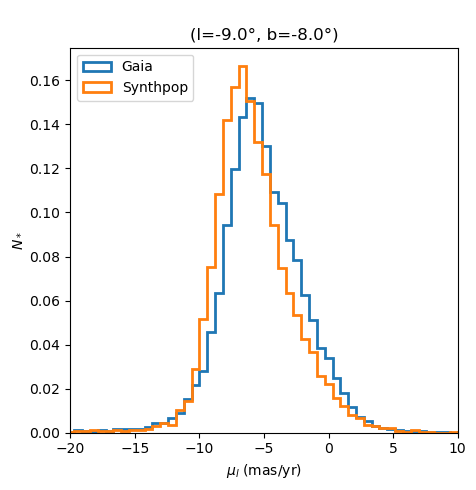

N stars (Gaia, SynthPop): 10991, 13111


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

l0, b0 = -9.0, -8.0
maglim = 20.0

gaia  = pd.read_csv(f"outputfiles/gaia_catalog_data/stars_l{l0:.3f}_b{b0:.3f}.csv")
synth = pd.read_csv(f"outputfiles/default/gaia_pm_l{l0:.3f}_b{b0:.3f}.csv")

g = gaia.loc[(gaia["phot_g_mean_mag"] < maglim) & gaia["pmra"].notna() & gaia["pmdec"].notna(),
             ["ra", "dec", "pmra", "pmdec"]]

c = SkyCoord(ra=g["ra"].to_numpy()*u.deg,
             dec=g["dec"].to_numpy()*u.deg,
             pm_ra_cosdec=g["pmra"].to_numpy()*(u.mas/u.yr),
             pm_dec=g["pmdec"].to_numpy()*(u.mas/u.yr),
             frame="icrs").galactic

pm_l_gaia = c.pm_l_cosb.to_value(u.mas/u.yr)

pm_l_synth = synth.loc[synth["Gaia_G_EDR3"] < maglim, "mul"].astype(float).to_numpy()

bins = np.linspace(-30, 30, 100)
plt.figure(figsize=(5,5))
plt.hist(pm_l_gaia[np.isfinite(pm_l_gaia)],  bins=bins, density = True, histtype="step", linewidth=2, label="Gaia")
plt.hist(pm_l_synth[np.isfinite(pm_l_synth)], bins=bins, density = True, histtype="step", linewidth=2, label="Synthpop")
plt.xlabel("$\mu_l$ (mas/yr)")
plt.ylabel("$N_*$")
plt.title(f"\n(l={l0:.1f}°, b={b0:.1f}°)")
plt.xlim(-20, 10)
plt.legend(loc="upper left", frameon=True)

plt.savefig("Synth-Gaia_new_run_histogram_4-5.pdf")

plt.show()

print(f"N stars (Gaia, SynthPop): {len(pm_l_gaia)}, {len(pm_l_synth)}")